In [1]:
import pandas as pd
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = r"C:/Users/alexa/OneDrive/Documentos/Curso5/Proyectos4/dataset_consumo_filtrado.csv"

df = pd.read_csv(file_path)  

In [3]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [5]:
print("Primeras filas del dataset:")
df.head()

Primeras filas del dataset:


,casa_id,timestamp,consumo_kwh,coste_euros
0,37,2017-05-31 01:00:00,0.176,0.026169
1,37,2017-05-31 02:00:00,0.222,0.030987
2,37,2017-05-31 03:00:00,0.195,0.026282
3,37,2017-05-31 04:00:00,0.163,0.023862
4,37,2017-05-31 05:00:00,0.235,0.037826


In [8]:
print("\nInformación del dataset:")
df.info()


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2668319 entries, 0 to 2668318
Data columns (total 4 columns):
 #   Column       Dtype  
---  ------       -----  
 0   casa_id      int64  
 1   timestamp    object 
 2   consumo_kwh  float64
 3   coste_euros  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 81.4+ MB


In [9]:
print("\nEstadísticas descriptivas:")
print(df.describe())


Estadísticas descriptivas:
            casa_id   consumo_kwh   coste_euros
count  2.668319e+06  2.668319e+06  2.668319e+06
mean   6.961804e+03  3.079666e-01  5.675147e-02
std    4.129984e+03  7.186142e-01  1.348363e-01
min    3.700000e+01  0.000000e+00  0.000000e+00
25%    3.315000e+03  5.600000e-02  9.229440e-03
50%    6.661000e+03  1.150000e-01  2.042172e-02
75%    1.066000e+04  2.790000e-01  5.181440e-02
max    1.550200e+04  1.506600e+01  3.201503e+00


In [21]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek

# es sabado
df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

# is saturday
df['is_saturday'] = df['dayofweek'] == 5

In [11]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
casa_id        0
timestamp      0
consumo_kwh    0
coste_euros    0
year           0
month          0
day            0
hour           0
dayofweek      0
dtype: int64


In [12]:
print("\nNúmero de registros duplicados:", df.duplicated().sum())


Número de registros duplicados: 0


In [13]:
# Filtrar datos de una casa para analizar (usaremos la casa 37 como ejemplo)
casa_sample = 37
df_casa = df[df['casa_id'] == casa_sample].copy()
df_casa = df_casa.sort_values('timestamp')

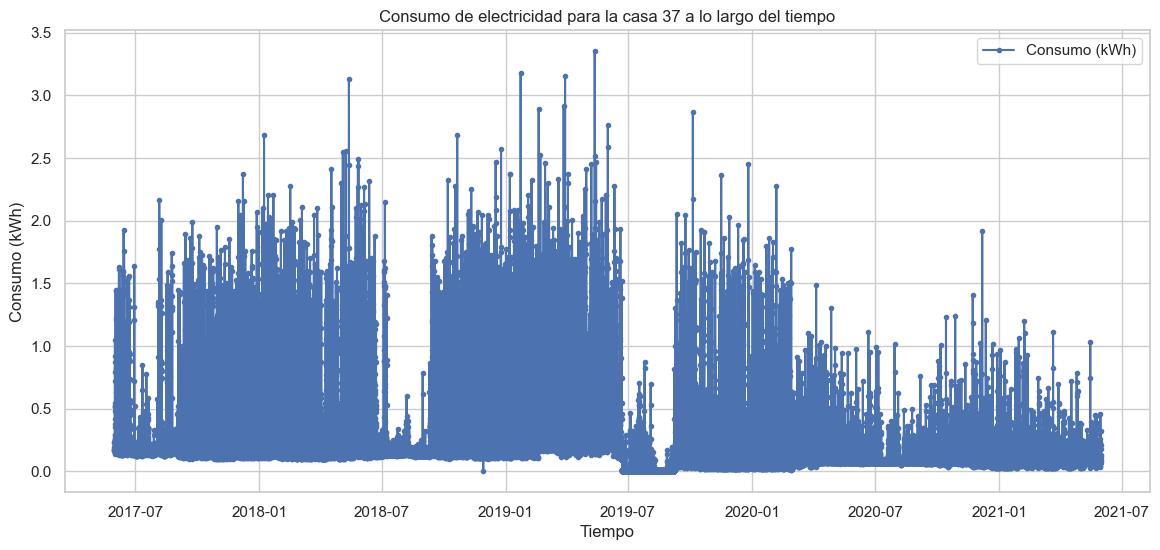

In [14]:
# 1. Gráfico de línea: Consumo a lo largo del tiempo para la casa 37
plt.figure(figsize=(14, 6))
plt.plot(df_casa['timestamp'], df_casa['consumo_kwh'], marker='.', linestyle='-', label='Consumo (kWh)')
plt.title(f'Consumo de electricidad para la casa {casa_sample} a lo largo del tiempo')
plt.xlabel('Tiempo')
plt.ylabel('Consumo (kWh)')
plt.legend()
plt.show()

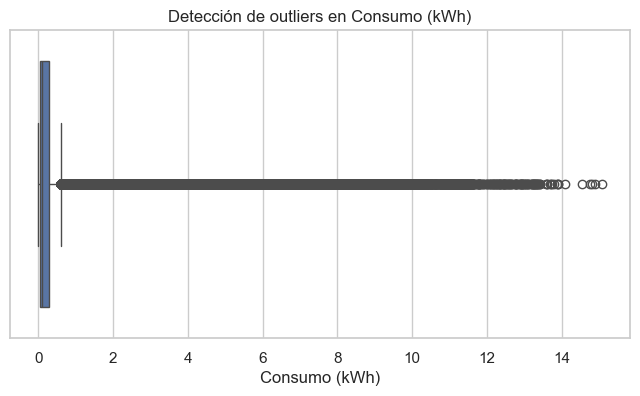

In [15]:
# 2. Boxplot: Detección de outliers en el consumo de electricidad
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['consumo_kwh'])
plt.title('Detección de outliers en Consumo (kWh)')
plt.xlabel('Consumo (kWh)')
plt.show()

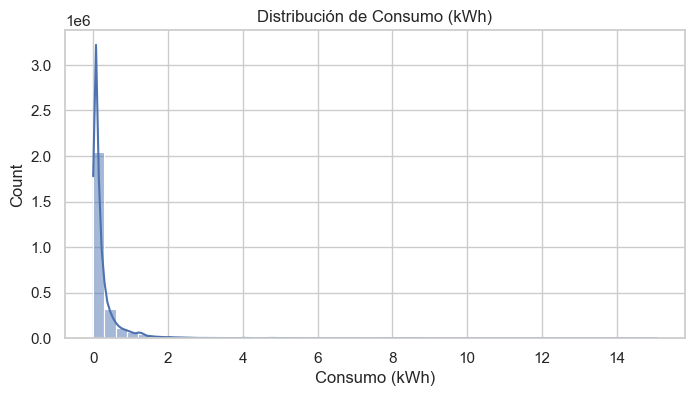

In [16]:
# 3. Histograma: Distribución del consumo de electricidad
plt.figure(figsize=(8, 4))
sns.histplot(df['consumo_kwh'], bins=50, kde=True)
plt.title('Distribución de Consumo (kWh)')
plt.xlabel('Consumo (kWh)')
plt.show()

### Correlación

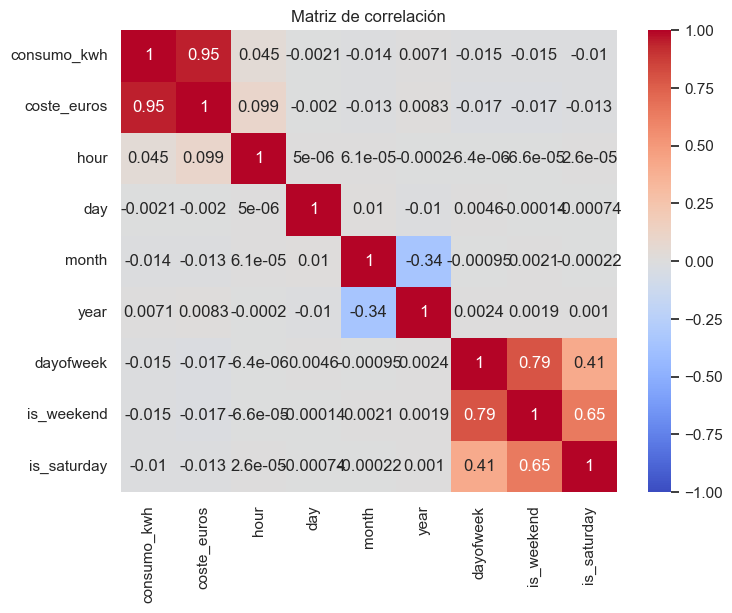

In [22]:
cols_interes = ['consumo_kwh', 'coste_euros', 'hour', 'day', 'month', 'year', 'dayofweek', 'is_weekend', 'is_saturday']
corr = df[cols_interes].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de correlación')
plt.show()

In [23]:
# --- 2. Tratamiento de outliers ---
# Vamos a usar el método del rango intercuartílico (IQR) en 'consumo_kwh'.

Q1 = df['consumo_kwh'].quantile(0.25)
Q3 = df['consumo_kwh'].quantile(0.75)
IQR = Q3 - Q1

# Definimos límites inferior y superior
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Limite inferior: {lower_bound}, Límite superior: {upper_bound}")


Limite inferior: -0.2785, Límite superior: 0.6135


In [24]:
# Creamos un dataframe filtrado
df_filtered = df[(df['consumo_kwh'] >= lower_bound) & (df['consumo_kwh'] <= upper_bound)].copy()

print(f"Registros originales: {len(df)}")
print(f"Registros después de filtrar: {len(df_filtered)}")

# Observamos cuántos outliers hemos 'perdido'
outliers_count = len(df) - len(df_filtered)
print(f"Registros considerados outliers y removidos: {outliers_count} ({outliers_count/len(df)*100:.2f}%)")


Registros originales: 2668319
Registros después de filtrar: 2371658
Registros considerados outliers y removidos: 296661 (11.12%)


In [25]:
# Bloque 4: Creación de dataset final para modelado

# 1. Decisión: no eliminamos outliers (conservamos df tal cual)
df_final = df.copy()

# 2. Creamos una versión transformada con log
df_final['consumo_log'] = np.log1p(df_final['consumo_kwh'])

# 3. Revisamos valores nulos (por si acaso)
print("Valores nulos en df_final:")
print(df_final.isnull().sum())

# 4. Guardamos ambos datasets
df_final.to_csv('datos_preprocesados_original.csv', index=False)
print("Dataset original (sin eliminar outliers) guardado en 'datos_preprocesados_original.csv'")

# (Opcional) Creamos un dataset con winsorización
import numpy as np

Q1 = df['consumo_kwh'].quantile(0.25)
Q3 = df['consumo_kwh'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_wins = df.copy()
df_wins.loc[df_wins['consumo_kwh'] < lower_bound, 'consumo_kwh'] = lower_bound
df_wins.loc[df_wins['consumo_kwh'] > upper_bound, 'consumo_kwh'] = upper_bound

df_wins.to_csv('datos_preprocesados_winsorizado.csv', index=False)
print("Dataset con winsorización guardado en 'datos_preprocesados_winsorizado.csv'")


Valores nulos en df_final:
casa_id        0
timestamp      0
consumo_kwh    0
coste_euros    0
year           0
month          0
day            0
hour           0
dayofweek      0
is_weekend     0
is_saturday    0
consumo_log    0
dtype: int64
Dataset original (sin eliminar outliers) guardado en 'datos_preprocesados_original.csv'
Dataset con winsorización guardado en 'datos_preprocesados_winsorizado.csv'
